In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [2]:
# Загружаем созданный файл
df = pd.read_csv('user_behavior.csv')

print("Данные загружены из CSV:")
print(f"Всего записей: {len(df)}")
print(f"\nИнформация о датасете:")
df.info()

Данные загружены из CSV:
Всего записей: 1000

Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   user_id                     1000 non-null   int64  
 1   app_version                 1000 non-null   float64
 2   device_type                 1000 non-null   str    
 3   session_duration_min        1000 non-null   float64
 4   screens_viewed              1000 non-null   int64  
 5   time_in_app_days            1000 non-null   float64
 6   push_notifications_enabled  1000 non-null   int64  
 7   support_tickets             1000 non-null   int64  
 8   converted                   1000 non-null   int64  
dtypes: float64(3), int64(5), str(1)
memory usage: 70.4 KB


ОПИСАТЕЛЬНАЯ СТАТИСТИКА
           user_id  app_version  session_duration_min  screens_viewed  \
count  1000.000000  1000.000000           1000.000000     1000.000000   
mean    500.500000     1.153400             14.565400        7.913000   
std     288.819436     0.115159             13.756433        2.620744   
min       1.000000     1.000000              0.000000        1.000000   
25%     250.750000     1.000000              4.475000        6.000000   
50%     500.500000     1.200000             10.600000        8.000000   
75%     750.250000     1.300000             20.125000       10.000000   
max    1000.000000     1.300000             60.000000       16.000000   

       time_in_app_days  push_notifications_enabled  support_tickets  \
count       1000.000000                 1000.000000      1000.000000   
mean          31.361000                    0.681000         0.507000   
std           32.844077                    0.466322         0.736542   
min            0.000000       

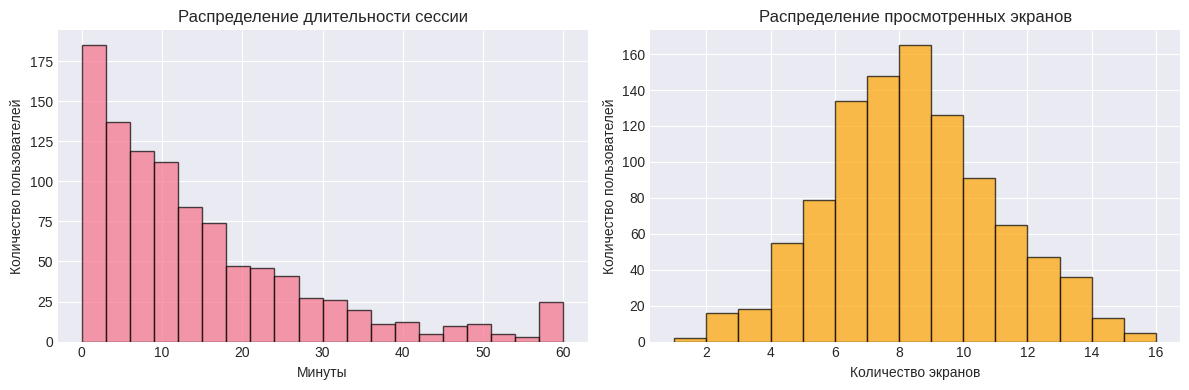


КОНВЕРСИЯ ПО ГРУППАМ

 По типу устройства:
              mean  count
device_type              
Android      0.630    598
iOS          0.617    402

 По версии приложения:
              mean  count
app_version              
1.0          0.543    258
1.1          0.683    230
1.2          0.659    232
1.3          0.625    280


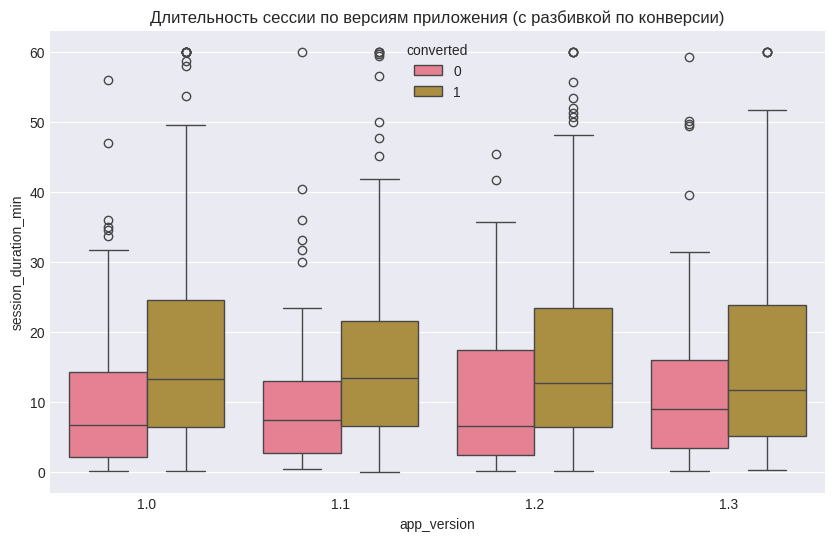

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 1. Описательная статистика
print("="*50)
print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА")
print("="*50)
print(df.describe())

# 2. Гистограммы
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['session_duration_min'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение длительности сессии')
axes[0].set_xlabel('Минуты')
axes[0].set_ylabel('Количество пользователей')

axes[1].hist(df['screens_viewed'], bins=15, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Распределение просмотренных экранов')
axes[1].set_xlabel('Количество экранов')
axes[1].set_ylabel('Количество пользователей')

plt.tight_layout()
plt.show()

# 3. Конверсия по устройству и версии
print("\n" + "="*50)
print("КОНВЕРСИЯ ПО ГРУППАМ")
print("="*50)

print("\n По типу устройства:")
print(df.groupby('device_type')['converted'].agg(['mean', 'count']).round(3))

print("\n По версии приложения:")
print(df.groupby('app_version')['converted'].agg(['mean', 'count']).round(3))

# 4. Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='app_version', y='session_duration_min', hue='converted', data=df)
plt.title('Длительность сессии по версиям приложения (с разбивкой по конверсии)')
plt.show()

КОРРЕЛЯЦИОННАЯ МАТРИЦА
                            session_duration_min  screens_viewed  \
session_duration_min                       1.000          -0.056   
screens_viewed                            -0.056           1.000   
time_in_app_days                           0.015          -0.013   
push_notifications_enabled                -0.007           0.050   
support_tickets                           -0.038          -0.042   
converted                                  0.216           0.073   

                            time_in_app_days  push_notifications_enabled  \
session_duration_min                   0.015                      -0.007   
screens_viewed                        -0.013                       0.050   
time_in_app_days                       1.000                      -0.009   
push_notifications_enabled            -0.009                       1.000   
support_tickets                        0.013                      -0.100   
converted                              0.021

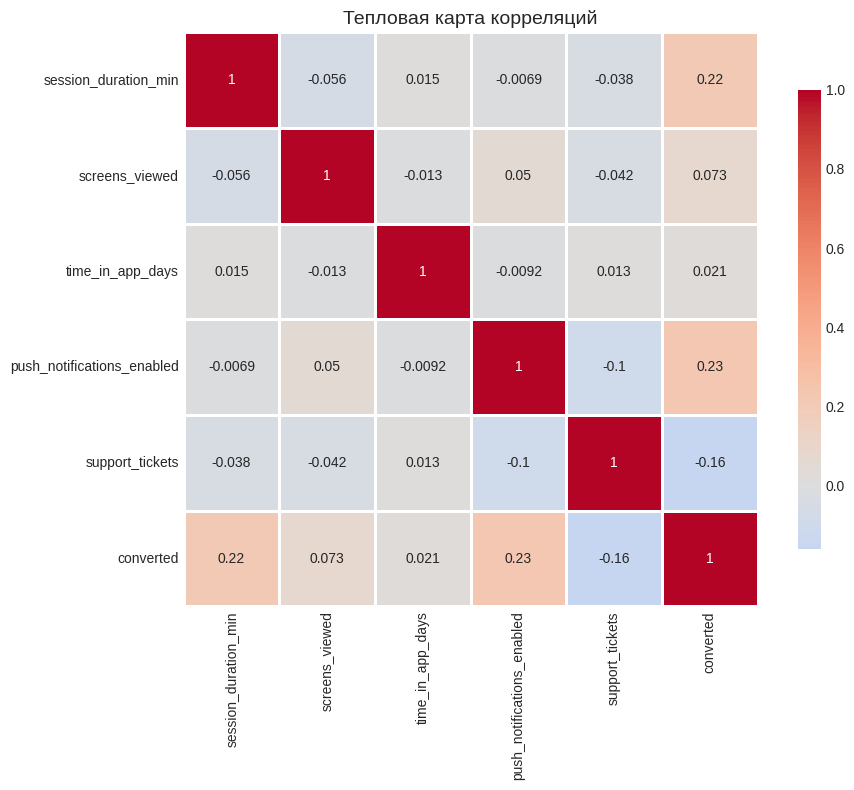

In [6]:
# 1. Корреляционная матрица
numeric_cols = ['session_duration_min', 'screens_viewed', 'time_in_app_days', 
                'push_notifications_enabled', 'support_tickets', 'converted']

corr_matrix = df[numeric_cols].corr()

print("="*50)
print("КОРРЕЛЯЦИОННАЯ МАТРИЦА")
print("="*50)
print(corr_matrix.round(3))

# 2. Топ-3 фактора, коррелирующих с конверсией
corr_with_conversion = corr_matrix['converted'].drop('converted').abs().sort_values(ascending=False)
print("\n Топ-3 фактора, влияющих на конверсию:")
for i, (factor, corr) in enumerate(corr_with_conversion.head(3).items(), 1):
    print(f"{i}. {factor}: {corr:.3f}")

# 3. Тепловая карта
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Тепловая карта корреляций', fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
# 1. Сегментация по времени использования
def segment_by_time(days):
    if days <= 7:
        return 'Новые (0-7 дней)'
    elif days <= 60:
        return 'Активные (8-60 дней)'
    else:
        return 'Старые (>60 дней)'

df['user_segment'] = df['time_in_app_days'].apply(segment_by_time)

print("="*50)
print("СЕГМЕНТАЦИЯ ПОЛЬЗОВАТЕЛЕЙ")
print("="*50)

segment_stats = df.groupby('user_segment').agg({
    'converted': 'mean',
    'session_duration_min': 'mean',
    'support_tickets': 'mean',
    'user_id': 'count'
}).round(3)

segment_stats.columns = ['Конверсия', 'Ср. длительность сессии', 'Ср. кол-во тикетов', 'Кол-во пользователей']
print(segment_stats)

# 2. Создание признака engaged
df['is_engaged'] = ((df['session_duration_min'] > 5) & (df['screens_viewed'] > 3)).astype(int)

print("\n" + "="*50)
print("АНАЛИЗ ENGAGED ПОЛЬЗОВАТЕЛЕЙ")
print("="*50)

engaged_stats = df.groupby('is_engaged')['converted'].agg(['mean', 'count'])
engaged_stats.index = ['Не вовлеченные', 'Вовлеченные']
engaged_stats.columns = ['Конверсия', 'Кол-во пользователей']
print(engaged_stats)
print(f"\nВовлеченные пользователи конвертируются в {engaged_stats.loc['Вовлеченные', 'Конверсия'] / engaged_stats.loc['Не вовлеченные', 'Конверсия']:.1f} раз чаще!")

СЕГМЕНТАЦИЯ ПОЛЬЗОВАТЕЛЕЙ
                      Конверсия  Ср. длительность сессии  Ср. кол-во тикетов  \
user_segment                                                                   
Активные (8-60 дней)      0.622                   14.321               0.522   
Новые (0-7 дней)          0.621                   14.950               0.485   
Старые (>60 дней)         0.644                   15.015               0.479   

                      Кол-во пользователей  
user_segment                                
Активные (8-60 дней)                   627  
Новые (0-7 дней)                       227  
Старые (>60 дней)                      146  

АНАЛИЗ ENGAGED ПОЛЬЗОВАТЕЛЕЙ
                Конверсия  Кол-во пользователей
Не вовлеченные   0.490260                   308
Вовлеченные      0.684971                   692

Вовлеченные пользователи конвертируются в 1.4 раз чаще!


In [8]:
from scipy import stats

# Гипотеза: push-уведомления повышают конверсию
push_on = df[df['push_notifications_enabled'] == 1]['converted']
push_off = df[df['push_notifications_enabled'] == 0]['converted']

print("="*50)
print("ПРОВЕРКА ГИПОТЕЗЫ: ВЛИЯНИЕ PUSH-УВЕДОМЛЕНИЙ")
print("="*50)

print(f"Конверсия с push (n={len(push_on)}): {push_on.mean()*100:.1f}%")
print(f"Конверсия без push (n={len(push_off)}): {push_off.mean()*100:.1f}%")
print(f"Разница: {(push_on.mean() - push_off.mean())*100:.1f} п.п.")

# t-test
t_stat, p_value = stats.ttest_ind(push_on, push_off)

print(f"\n Результаты t-test:")
print(f"t-статистика: {t_stat:.3f}")
print(f"p-value: {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print(f"\n Отвергаем нулевую гипотезу (p < {alpha})")
    print("   Push-уведомления статистически значимо влияют на конверсию")
else:
    print(f"\n Не отвергаем нулевую гипотезу (p >= {alpha})")
    print("   Разница в конверсии статистически не значима")

ПРОВЕРКА ГИПОТЕЗЫ: ВЛИЯНИЕ PUSH-УВЕДОМЛЕНИЙ
Конверсия с push (n=681): 70.2%
Конверсия без push (n=319): 46.1%
Разница: 24.1 п.п.

 Результаты t-test:
t-статистика: 7.539
p-value: 0.000000

 Отвергаем нулевую гипотезу (p < 0.05)
   Push-уведомления статистически значимо влияют на конверсию


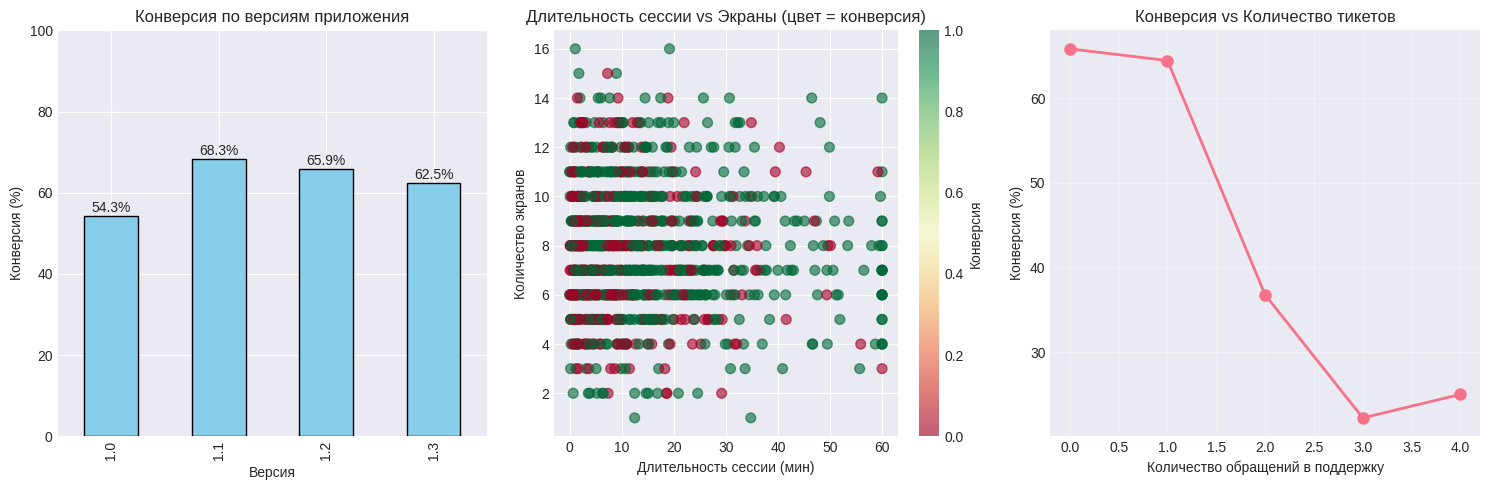


КЛЮЧЕВЫЕ ВЫВОДЫ

1.  Общая конверсия: 62.5%
2.  Лучшая версия приложения: 1.1 (68.3% конверсии)
3.  Худшая версия приложения: 1.0 (54.3% конверсии)
4.  Корреляция с конверсией:
   - screens_viewed: 0.073
   - session_duration: 0.216
   - support_tickets: -0.160
5.  Вовлеченные пользователи конвертируются в 1.4 раз чаще



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Убедимся, что df загружен
if 'df' not in globals():
    df = pd.read_csv('user_behavior.csv')

# Создаем необходимые переменные для визуализации
version_conversion = df.groupby('app_version')['converted'].mean() * 100

# Корреляция для выводов
numeric_cols = ['session_duration_min', 'screens_viewed', 'time_in_app_days', 
                'push_notifications_enabled', 'support_tickets', 'converted']
corr_matrix = df[numeric_cols].corr()

# Данные для вовлеченности
df['is_engaged'] = ((df['session_duration_min'] > 5) & (df['screens_viewed'] > 3)).astype(int)
engaged_stats = df.groupby('is_engaged')['converted'].agg(['mean', 'count'])

# Создаем dashboard из 3 графиков
fig = plt.figure(figsize=(15, 5))

# График 1: Конверсия по версиям
ax1 = fig.add_subplot(131)
version_conversion.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('Конверсия по версиям приложения', fontsize=12)
ax1.set_xlabel('Версия')
ax1.set_ylabel('Конверсия (%)')
ax1.set_ylim(0, 100)
for i, v in enumerate(version_conversion):
    ax1.text(i, v + 1, f'{v:.1f}%', ha='center')

# График 2: Scatter plot
ax2 = fig.add_subplot(132)
scatter = ax2.scatter(df['session_duration_min'], df['screens_viewed'], 
                     c=df['converted'], cmap='RdYlGn', alpha=0.6, s=50)
ax2.set_title('Длительность сессии vs Экраны (цвет = конверсия)', fontsize=12)
ax2.set_xlabel('Длительность сессии (мин)')
ax2.set_ylabel('Количество экранов')
plt.colorbar(scatter, ax=ax2, label='Конверсия')

# График 3: Конверсия по тикетам
ax3 = fig.add_subplot(133)
ticket_conversion = df.groupby('support_tickets')['converted'].mean() * 100
ax3.plot(ticket_conversion.index, ticket_conversion.values, marker='o', linewidth=2, markersize=8)
ax3.set_title('Конверсия vs Количество тикетов', fontsize=12)
ax3.set_xlabel('Количество обращений в поддержку')
ax3.set_ylabel('Конверсия (%)')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Финальная статистика
print("\n" + "="*50)
print("КЛЮЧЕВЫЕ ВЫВОДЫ")
print("="*50)

# Проверяем, что данные существуют
if len(version_conversion) > 0:
    best_version = version_conversion.idxmax()
    best_conversion = version_conversion.max()
    worst_version = version_conversion.idxmin()
    worst_conversion = version_conversion.min()
else:
    best_version = "N/A"
    best_conversion = 0
    worst_version = "N/A"
    worst_conversion = 0

# Безопасное получение значений корреляции
try:
    corr_screens = corr_matrix.loc['screens_viewed', 'converted']
except:
    corr_screens = 0
    
try:
    corr_duration = corr_matrix.loc['session_duration_min', 'converted']
except:
    corr_duration = 0
    
try:
    corr_tickets = corr_matrix.loc['support_tickets', 'converted']
except:
    corr_tickets = 0

# Безопасное получение данных о вовлеченности
if len(engaged_stats) > 1:
    engaged_ratio = engaged_stats.loc[1, 'mean'] / engaged_stats.loc[0, 'mean']
else:
    engaged_ratio = 0

print(f"""
1.  Общая конверсия: {df['converted'].mean()*100:.1f}%
2.  Лучшая версия приложения: {best_version} ({best_conversion:.1f}% конверсии)
3.  Худшая версия приложения: {worst_version} ({worst_conversion:.1f}% конверсии)
4.  Корреляция с конверсией:
   - screens_viewed: {corr_screens:.3f}
   - session_duration: {corr_duration:.3f}
   - support_tickets: {corr_tickets:.3f}
5.  Вовлеченные пользователи конвертируются в {engaged_ratio:.1f} раз чаще
""")